# 03 - Analise exploratoria e hipoteses

## tl;dr
Este notebook explora a distribuicao do custo por km, compara segmentos e avalia as hipoteses de negocio com correlacoes e evidencias descritivas.

## Context & Methods

A EDA deve orientar a modelagem e evitar conclusoes fortes sem evidencias. O foco e identificar padroes consistentes e variaveis candidatas.

### Key Assumptions
- A base mensal nominal ja foi gerada pelo notebook 02.
- O alvo primario da EDA e `custo_manutencao_preventiva_por_km`.
- Meses abaixo do piso de quilometragem nao entram na analise de custo por km.
- A EDA principal usa a populacao `MAINT`, alinhada ao notebook de modelagem.
- Hipoteses sobre custo por km sao lidas em duas partes: ocorrencia de custo e magnitude condicional nos meses positivos.
- Resultados exploratorios indicam associacoes, nao causalidade.

In [56]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".cache" / "matplotlib"))
(PROJECT_ROOT / ".cache" / "matplotlib").mkdir(parents=True, exist_ok=True)

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures"
TABLES = REPORTS / "tables"
ANALYSIS_START = pd.Timestamp("2020-01-01")
ANALYSIS_END_EXCLUSIVE = pd.Timestamp("2026-01-01")
ANALYSIS_END = pd.Timestamp("2025-12-31")
KM_MIN_MES_ALVO = 500.0
PREVENTIVE_VMRS_CODES = {"PM"}

for path in [DATA_INTERIM, DATA_PROCESSED, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

FILES = {
    "dim_carretas": DATA_RAW / "dim_carretas_2020-01-01_to_2025-12-31.csv",
    "fato_contratos": DATA_RAW / "fato_contratos_2020-01-01_to_2025-12-31.csv",
    "fato_gps": DATA_RAW / "fato_gps_2020-01-01_to_2025-12-31.csv",
    "fato_readings": DATA_RAW / "fato_readings_2020-01-01_to_2025-12-31.csv",
    "fato_wo": DATA_RAW / "fato_wo_2020-01-01_to_2025-12-31.csv",
    "fato_wo_labour": DATA_RAW / "fato_wo_labour_2020-01-01_to_2025-12-31.csv",
    "fato_wo_parts": DATA_RAW / "fato_wo_parts_2020-01-01_to_2025-12-31.csv",
}

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    return df

def read_csv(name: str, **kwargs) -> pd.DataFrame:
    return normalize_columns(pd.read_csv(FILES[name], low_memory=False, **kwargs))

def month_start(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce").dt.to_period("M").dt.to_timestamp()

def as_number(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def mode_or_unknown(series: pd.Series, unknown: str = "SEM_INFORMACAO") -> str:
    values = series.dropna().astype(str)
    if values.empty:
        return unknown
    return values.mode().iloc[0]

## Data

### 1. Carregar base mensal

In [57]:
base_path = DATA_PROCESSED / "base_mensal_carreta.csv"
base = pd.read_csv(base_path, parse_dates=["ano_mes", "data_entrada_servico"], low_memory=False)

analise_todos = base.replace([np.inf, -np.inf], np.nan).copy()
target = "custo_manutencao_preventiva_por_km"
target_label = "Custo preventivo por km"
analise_todos = analise_todos[analise_todos[target].notna()].copy()
analise_todos = analise_todos[analise_todos["km_valido_modelagem_flag"].eq(1)].copy()
analise = analise_todos[analise_todos["tipo_manutencao"].eq("MAINT")].copy()
analise["ocorrencia_custo_preventivo"] = (analise["custo_preventivo_total_mes"] > 0).astype(int)
analise_positiva = analise[analise["ocorrencia_custo_preventivo"].eq(1)].copy()

pd.DataFrame([
    {"recorte": "todos_com_km_valido", "linhas": len(analise_todos), "share_zero": float((analise_todos["custo_preventivo_total_mes"] == 0).mean())},
    {"recorte": "MAINT_modelagem", "linhas": len(analise), "share_zero": float((analise["custo_preventivo_total_mes"] == 0).mean())},
    {"recorte": "MAINT_custo_positivo", "linhas": len(analise_positiva), "share_zero": 0.0},
])

,recorte,linhas,share_zero
0,todos_com_km_valido,352066,0.804966
1,MAINT_modelagem,332756,0.797786
2,MAINT_custo_positivo,67285,0.000000


### 2. Preparar bibliotecas graficas

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Results

### 3. Distribuicao do custo por km

In [59]:
distribution = analise[target].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("valor")
distribution.loc["assimetria"] = analise[target].skew()
distribution.loc["share_zero_preventivo"] = (analise["custo_preventivo_total_mes"] == 0).mean()
distribution.loc["km_minimo_alvo"] = KM_MIN_MES_ALVO
distribution.to_csv(TABLES / "03_distribuicao_custo_por_km.csv")
distribution

,valor
count,332756.000000
mean,0.029045
std,0.172584
min,-0.049429
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
95%,0.129995


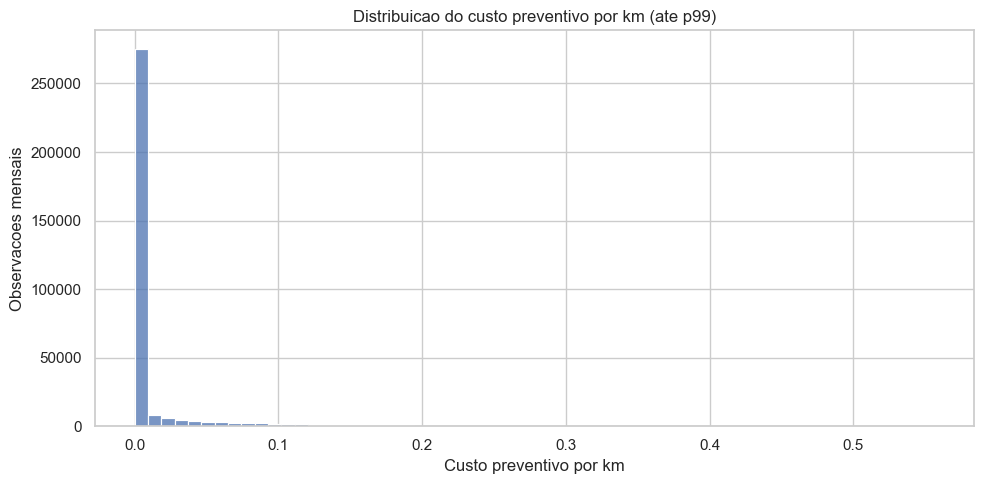

In [60]:
p99 = analise[target].quantile(0.99)
fig, ax = plt.subplots()
sns.histplot(analise.loc[analise[target].between(0, p99), target], bins=60, ax=ax)
ax.set_title("Distribuicao do custo preventivo por km (ate p99)")
ax.set_xlabel(target_label)
ax.set_ylabel("Observacoes mensais")
fig.tight_layout()
fig.savefig(FIGURES / "03_distribuicao_custo_por_km.png", dpi=160)
plt.show()

### 4. Evolucao temporal

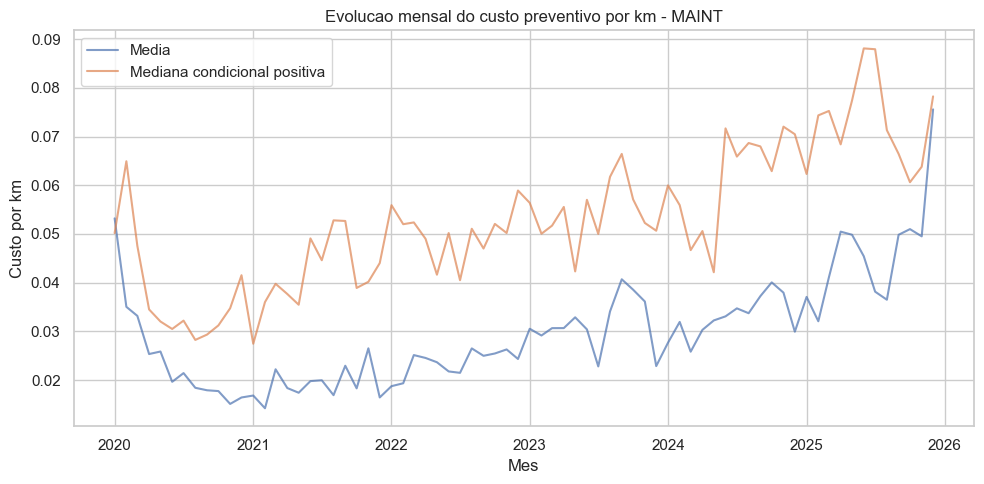

In [61]:
temporal = (
    analise.groupby("ano_mes", as_index=False)
    .agg(
        custo_por_km_medio=(target, "mean"),
        custo_por_km_mediano=(target, "median"),
        custo_por_km_mediano_positivo=(target, lambda s: s[s > 0].median()),
        taxa_ocorrencia=("ocorrencia_custo_preventivo", "mean"),
        km_total=("km_rodado_mes", "sum"),
        custo_preventivo_total=("custo_preventivo_total_mes", "sum"),
        custo_total=("custo_total_mes", "sum"),
        observacoes=("id_carreta", "count"),
    )
)
temporal.to_csv(TABLES / "03_evolucao_temporal.csv", index=False)

fig, ax = plt.subplots()
ax.plot(temporal["ano_mes"], temporal["custo_por_km_medio"], label="Media", alpha=0.7)
ax.plot(temporal["ano_mes"], temporal["custo_por_km_mediano_positivo"], label="Mediana condicional positiva", alpha=0.7)
ax.set_title("Evolucao mensal do custo preventivo por km - MAINT")
ax.set_xlabel("Mes")
ax.set_ylabel("Custo por km")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "03_evolucao_custo_por_km.png", dpi=160)
plt.show()

### 5. Comparacoes por segmentos

In [62]:
def segment_summary(col: str, min_obs: int = 100) -> pd.DataFrame:
    out = (
        analise.groupby(col, dropna=False)
        .agg(
            observacoes=(target, "count"),
            custo_por_km_mediano=(target, "median"),
            custo_por_km_mediano_positivo=(target, lambda s: s[s > 0].median()),
            custo_por_km_medio=(target, "mean"),
            taxa_ocorrencia=("ocorrencia_custo_preventivo", "mean"),
            km_mediano=("km_rodado_mes", "median"),
            custo_preventivo_total=("custo_preventivo_total_mes", "sum"),
            custo_total=("custo_total_mes", "sum"),
        )
        .reset_index()
    )
    return out[out["observacoes"] >= min_obs].sort_values("custo_por_km_medio", ascending=False)

segmentos = {}
for col in ["cod_montadora", "ano_modelo", "flag_refrigerado", "tipo_contrato", "cod_grupo_manutencao", "regiao_operacao"]:
    if col in analise.columns:
        segmentos[col] = segment_summary(col)
        segmentos[col].to_csv(TABLES / f"03_segmento_{col}.csv", index=False)

segmento_tipo_manutencao_todos = (
    analise_todos.groupby("tipo_manutencao", dropna=False)
    .agg(
        observacoes=(target, "count"),
        custo_por_km_medio=(target, "mean"),
        custo_por_km_mediano_positivo=(target, lambda s: s[s > 0].median()),
        taxa_ocorrencia=("custo_preventivo_total_mes", lambda s: float((s > 0).mean())),
        custo_preventivo_total=("custo_preventivo_total_mes", "sum"),
    )
    .reset_index()
)
segmento_tipo_manutencao_todos.to_csv(TABLES / "03_segmento_tipo_manutencao_todos.csv", index=False)

segmentos["cod_montadora"].head(10)

,cod_montadora,observacoes,custo_por_km_mediano,custo_por_km_mediano_positivo,custo_por_km_medio,taxa_ocorrencia,km_mediano,custo_preventivo_total,custo_total
10,TRANSC,386,0.0,0.243890,0.044877,0.106218,1775.931061,23285.89,75271.47
0,DI-MOND,465,0.0,0.184763,0.043196,0.075269,1081.583082,21332.52,51872.15
11,UTLTY,151522,0.0,0.043400,0.032849,0.246109,2074.426365,9421307.24,32060447.38
14,WABASH,30089,0.0,0.073894,0.031807,0.166074,2293.827657,1767764.64,5447456.75
9,TMOBILE,8484,0.0,0.155445,0.028907,0.084394,913.652911,235694.37,812423.84
1,GRTDNE,6911,0.0,0.096298,0.028408,0.125163,1457.911190,312469.17,1013701.00
7,STGHTN,59333,0.0,0.085021,0.025922,0.143731,1209.241367,1973804.86,6281652.99
2,HYUNDAI,36006,0.0,0.037294,0.023899,0.240627,2814.418102,1824221.82,5291323.30
12,VGUARD,902,0.0,0.136796,0.023245,0.095344,1198.037907,21430.53,96389.68
3,ITD,5115,0.0,0.053387,0.022297,0.154839,2256.221667,184420.55,565707.07


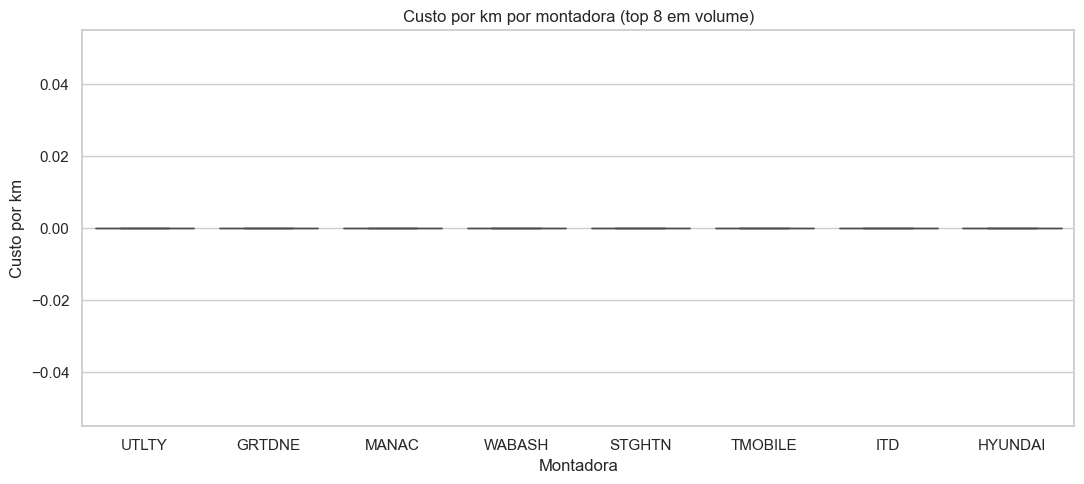

In [63]:
top_makes = analise["cod_montadora"].value_counts().head(8).index
plot_data = analise[analise["cod_montadora"].isin(top_makes) & (analise[target] <= p99)].copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=plot_data, x="cod_montadora", y=target, ax=ax, showfliers=False)
ax.set_title("Custo por km por montadora (top 8 em volume)")
ax.set_xlabel("Montadora")
ax.set_ylabel("Custo por km")
fig.tight_layout()
fig.savefig(FIGURES / "03_boxplot_montadora.png", dpi=160)
plt.show()

### 6. Correlacoes Pearson e Spearman

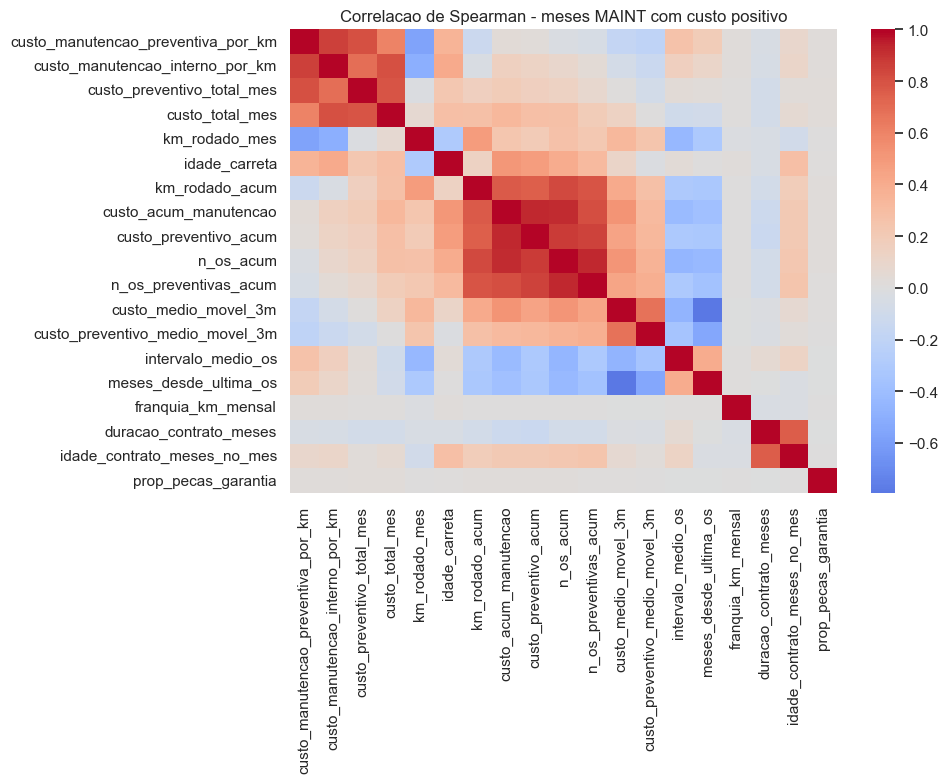

,spearman_base_maint,spearman_magnitude_positivos,spearman_ocorrencia
custo_manutencao_preventiva_por_km,1.000000,1.000000,0.991549
custo_manutencao_interno_por_km,0.727792,0.857922,0.714230
custo_preventivo_total_mes,0.996749,0.806413,0.991549
custo_total_mes,0.712612,0.606453,0.704925
km_rodado_mes,0.047633,-0.571738,0.081294
idade_carreta,-0.044433,0.353555,-0.067770
intervalo_medio_os,-0.125700,0.260730,-0.141399
custo_preventivo_medio_movel_3m,-0.132849,-0.204785,-0.123146
meses_desde_ultima_os,0.060003,0.192935,0.049716
custo_medio_movel_3m,-0.055841,-0.172400,-0.046198


In [64]:
numeric_candidates = [
    "custo_manutencao_preventiva_por_km", "custo_manutencao_interno_por_km",
    "custo_preventivo_total_mes", "custo_total_mes", "km_rodado_mes",
    "idade_carreta", "km_rodado_acum", "custo_acum_manutencao", "custo_preventivo_acum",
    "n_os_acum", "n_os_preventivas_acum", "custo_medio_movel_3m", "custo_preventivo_medio_movel_3m",
    "intervalo_medio_os", "meses_desde_ultima_os", "franquia_km_mensal",
    "duracao_contrato_meses", "idade_contrato_meses_no_mes", "prop_pecas_garantia",
]
numeric_candidates = [c for c in numeric_candidates if c in analise.columns]
corr_pearson = analise[numeric_candidates].corr(method="pearson")
corr_spearman = analise[numeric_candidates].corr(method="spearman")
corr_spearman_positivos = analise_positiva[numeric_candidates].corr(method="spearman")
corr_ocorrencia = analise[numeric_candidates + ["ocorrencia_custo_preventivo"]].corr(method="spearman")["ocorrencia_custo_preventivo"].drop("ocorrencia_custo_preventivo")
corr_pearson.to_csv(TABLES / "03_correlacao_pearson.csv")
corr_spearman.to_csv(TABLES / "03_correlacao_spearman.csv")
corr_spearman_positivos.to_csv(TABLES / "03_correlacao_spearman_positivos.csv")
corr_ocorrencia.to_frame("spearman_ocorrencia").to_csv(TABLES / "03_correlacao_ocorrencia.csv")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman_positivos, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlacao de Spearman - meses MAINT com custo positivo")
fig.tight_layout()
fig.savefig(FIGURES / "03_correlacao_spearman.png", dpi=160)
plt.show()

pd.DataFrame({
    "spearman_base_maint": corr_spearman[target],
    "spearman_magnitude_positivos": corr_spearman_positivos[target],
    "spearman_ocorrencia": corr_ocorrencia,
}).sort_values("spearman_magnitude_positivos", key=lambda s: s.abs(), ascending=False)

### 7. Componentes/sistemas VMRS

In [65]:
labour = read_csv("fato_wo_labour", usecols=["ID_CARRETA", "DATA_OS", "COD_SISTEMA_VMRS", "SISTEMA_VMRS", "CUSTO_INTERNO_MAO_OBRA"])
labour["data_os"] = pd.to_datetime(labour["data_os"], errors="coerce")
labour = labour[labour["data_os"] < pd.Timestamp("2026-01-01")].copy()
labour["custo_interno_mao_obra"] = as_number(labour["custo_interno_mao_obra"]).fillna(0)

vmrs = (
    labour.groupby(["cod_sistema_vmrs", "sistema_vmrs"], dropna=False, as_index=False)
    .agg(custo_mao_obra=("custo_interno_mao_obra", "sum"), linhas=("custo_interno_mao_obra", "count"))
    .sort_values("custo_mao_obra", ascending=False)
)
vmrs["share_custo"] = vmrs["custo_mao_obra"] / vmrs["custo_mao_obra"].sum()
vmrs.to_csv(TABLES / "03_custo_por_sistema_vmrs.csv", index=False)
vmrs.head(15)

,cod_sistema_vmrs,sistema_vmrs,custo_mao_obra,linhas,share_custo
9,10,REEFER,7387141.01,100901,0.179734
19,PM,PREVENTIVE MAINTENANCE,6325427.87,127684,0.153902
3,04,BRAKES,5832032.32,102478,0.141897
8,09,TIRES AND ACCESSORIES (ATA 017),3986139.37,59780,0.096985
1,02,AIR EQUIPMENT,2775044.40,63288,0.067519
21,SC,SERVICE CALL,2759420.72,46353,0.067139
0,01,MISCELLANEOUS,2578598.07,45222,0.062739
7,08,EXTERIOR BODY,1855732.82,47431,0.045151
2,03,LIGHTS AND WIRING,1841576.56,41944,0.044807
5,06,BOGIE,1324337.60,18232,0.032222


### 8. Sintese das hipoteses

In [66]:
def status_corr(value: float) -> str:
    if pd.isna(value):
        return "inconclusiva"
    if abs(value) >= 0.30:
        return "suportada"
    if abs(value) >= 0.10:
        return "parcialmente suportada"
    return "nao suportada nesta EDA"

def safe_ratio(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").replace(0, np.nan).dropna()
    if len(values) < 2:
        return np.nan
    min_value = values.min()
    return np.nan if min_value == 0 else values.max() / min_value

def occurrence_by_quantile(col: str, q: int = 5) -> pd.DataFrame:
    tmp = analise[[col, "ocorrencia_custo_preventivo"]].dropna().copy()
    if tmp[col].nunique() < 2:
        return pd.DataFrame(columns=["variavel", "faixa", "observacoes", "taxa_ocorrencia"])
    tmp["faixa"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    out = (
        tmp.groupby("faixa", observed=True)
        .agg(
            observacoes=("ocorrencia_custo_preventivo", "count"),
            taxa_ocorrencia=("ocorrencia_custo_preventivo", "mean"),
        )
        .reset_index()
    )
    out.insert(0, "variavel", col)
    out["faixa"] = out["faixa"].astype(str)
    return out

def occurrence_spread(col: str) -> float:
    out = occurrence_by_quantile(col)
    if out.empty:
        return np.nan
    return float(out["taxa_ocorrencia"].max() - out["taxa_ocorrencia"].min())

ocorrencia_faixas = pd.concat(
    [occurrence_by_quantile(col) for col in ["idade_carreta", "km_rodado_mes", "duracao_contrato_meses", "custo_preventivo_acum"]],
    ignore_index=True,
)
ocorrencia_faixas.to_csv(TABLES / "03_ocorrencia_por_faixa.csv", index=False)

spearman_target = corr_spearman[target]
spearman_target_pos = corr_spearman_positivos[target]
spearman_preventive_cost = corr_spearman["custo_preventivo_total_mes"] if "custo_preventivo_total_mes" in corr_spearman.columns else pd.Series(dtype=float)
contrato_seg = segmentos.get("tipo_contrato", pd.DataFrame())
contrato_ratio = np.nan
if len(contrato_seg) >= 2:
    contrato_ratio = safe_ratio(contrato_seg["custo_por_km_medio"])
contrato_ratio_positivo = safe_ratio(contrato_seg["custo_por_km_mediano_positivo"]) if len(contrato_seg) >= 2 else np.nan
tipo_manutencao_seg = segmento_tipo_manutencao_todos
tipo_manutencao_ratio = np.nan
if len(tipo_manutencao_seg) >= 2:
    tipo_manutencao_ratio = safe_ratio(tipo_manutencao_seg["custo_por_km_medio"])

historico_features = [
    "custo_preventivo_acum",
    "n_os_preventivas_acum",
    "n_os_acum",
    "custo_preventivo_medio_movel_3m",
    "intervalo_medio_os",
    "meses_desde_ultima_os",
    "custo_acum_manutencao",
    "custo_medio_movel_3m",
]
historico_rows = []
for col in historico_features:
    historico_rows.append({
        "feature": col,
        "spearman_ocorrencia": corr_ocorrencia.get(col, np.nan),
        "spearman_magnitude_positiva": spearman_target_pos.get(col, np.nan),
    })
historico_proxies = pd.DataFrame(historico_rows)
historico_proxies["max_abs_spearman"] = historico_proxies[
    ["spearman_ocorrencia", "spearman_magnitude_positiva"]
].abs().max(axis=1)
historico_proxies = historico_proxies.sort_values("max_abs_spearman", ascending=False)
historico_proxies.to_csv(TABLES / "03_historico_manutencao_proxies.csv", index=False)
historico_max_abs = historico_proxies["max_abs_spearman"].max() if len(historico_proxies) else np.nan
historico_top_evidencia = "; ".join(
    [
        f"{row.feature}: ocorrencia={row.spearman_ocorrencia:.3f}, magnitude={row.spearman_magnitude_positiva:.3f}"
        for row in historico_proxies.head(4).itertuples()
    ]
)
historico_status = "parcialmente suportada" if pd.notna(historico_max_abs) and historico_max_abs >= 0.10 else "nao suportada nesta EDA"

vmrs_top5_share = vmrs.head(5)["share_custo"].sum() if len(vmrs) else np.nan

hipoteses = pd.DataFrame([
    {
        "hipotese": "Contratos de maior duracao tendem a maior custo por km",
        "evidencia": (
            f"Ocorrencia: Spearman = {corr_ocorrencia.get('duracao_contrato_meses', np.nan):.3f}; "
            f"magnitude positiva: Spearman duracao vs custo/km = {spearman_target_pos.get('duracao_contrato_meses', np.nan):.3f}"
        ),
        "status": status_corr(spearman_target_pos.get("duracao_contrato_meses", np.nan)),
    },
    {
        "hipotese": "Carretas mais antigas tendem a ter maior custo por km",
        "evidencia": (
            f"Ocorrencia: Spearman = {corr_ocorrencia.get('idade_carreta', np.nan):.3f}; "
            f"spread de taxa por quintil = {occurrence_spread('idade_carreta'):.3f}; "
            f"magnitude positiva: Spearman idade vs custo/km = {spearman_target_pos.get('idade_carreta', np.nan):.3f}"
        ),
        "status": status_corr(spearman_target_pos.get("idade_carreta", np.nan)),
    },
    {
        "hipotese": "Maior quilometragem mensal esta associada ao custo absoluto",
        "evidencia": (
            f"Spearman km_rodado_mes vs custo_preventivo_total_mes = {spearman_preventive_cost.get('km_rodado_mes', np.nan):.3f}; "
            f"ocorrencia = {corr_ocorrencia.get('km_rodado_mes', np.nan):.3f}; "
            f"custo/km positivo = {spearman_target_pos.get('km_rodado_mes', np.nan):.3f} (relacao mecanica com denominador)"
        ),
        "status": status_corr(spearman_preventive_cost.get("km_rodado_mes", np.nan)),
    },
    {
        "hipotese": "Historico de manutencoes ajuda a prever custo futuro",
        "evidencia": (
            f"Maior |Spearman| entre proxies historicos = {historico_max_abs:.3f}; "
            f"principais proxies: {historico_top_evidencia}"
        ),
        "status": historico_status,
    },
    {
        "hipotese": "Caracteristicas contratuais influenciam o custo",
        "evidencia": (
            f"Razao media por tipo_contrato em MAINT = {contrato_ratio:.2f}; "
            f"mediana positiva = {contrato_ratio_positivo:.2f}; "
            f"tipo_manutencao na base completa e caveat estrutural NET/MIX, nao tamanho de efeito ({tipo_manutencao_ratio:.2f})"
        ),
        "status": "parcialmente suportada" if any(pd.notna(v) and v >= 1.10 for v in [contrato_ratio, contrato_ratio_positivo]) else "inconclusiva",
    },
    {
        "hipotese": "Componentes/sistemas concentram parte relevante do custo",
        "evidencia": f"Top 5 sistemas VMRS representam {vmrs_top5_share:.1%} do custo de mao de obra",
        "status": "suportada" if pd.notna(vmrs_top5_share) and vmrs_top5_share >= 0.50 else "parcialmente suportada",
    },
])

hipoteses.to_csv(TABLES / "03_sintese_hipoteses.csv", index=False)
features_candidatas = pd.DataFrame({"feature": [
    "idade_carreta", "km_rodado_mes", "km_rodado_acum", "custo_acum_manutencao",
    "custo_preventivo_acum", "n_os_acum", "n_os_preventivas_acum",
    "custo_medio_movel_3m", "custo_preventivo_medio_movel_3m", "intervalo_medio_os",
    "cod_montadora", "cod_modelo", "flag_refrigerado", "tipo_contrato",
    "tipo_manutencao", "franquia_km_mensal", "duracao_contrato_meses",
    "regiao_operacao", "cod_grupo_manutencao",
]})
features_candidatas.to_csv(TABLES / "03_features_candidatas.csv", index=False)
hipoteses

,hipotese,evidencia,status
0,Contratos de maior duracao tendem a maior cust...,Ocorrencia: Spearman = 0.029; magnitude positi...,nao suportada nesta EDA
1,Carretas mais antigas tendem a ter maior custo...,Ocorrencia: Spearman = -0.068; spread de taxa ...,suportada
2,Maior quilometragem mensal esta associada ao c...,Spearman km_rodado_mes vs custo_preventivo_tot...,nao suportada nesta EDA
3,Historico de manutencoes ajuda a prever custo ...,Maior |Spearman| entre proxies historicos = 0....,parcialmente suportada
4,Caracteristicas contratuais influenciam o custo,Razao media por tipo_contrato em MAINT = 1.50;...,parcialmente suportada
5,Componentes/sistemas concentram parte relevant...,Top 5 sistemas VMRS representam 64.0% do custo...,suportada


## Takeaways

- A distribuicao do custo por km e zero-inflada e assimetrica, exigindo leitura separada de ocorrencia e magnitude.
- A EDA principal esta alinhada a populacao `MAINT`, usada na modelagem.
- As hipoteses devem ser interpretadas como evidencias associativas, nao causais.
- As variaveis mais promissoras seguem para a modelagem no notebook 05.